In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [9]:
calib = [
[4, 3288, 3320],
[3, 2786, 2819],
[2, 2351, 2380],
[1, 1943,1965],
[-3, 202, 193],
[-2, 603, 597],
[-1.02, 997, 995],
[-1, 1007, 1002],
[-0.9, 1050,1047],
[-0.8,1090,1088],
[-0.7, 1131, 1128],
[-0.6, 1173,1171],
[-0.5,1214,1213],
[-0.4,1257,1255],
[-0.3,1300,1298],
[-0.2,1341,1340],
[-0.1,1383,1383],
[0.1,1463,1463],
[0.2,1506,1506],
[0.3,1628,1656],
[0.4,1676,1700],
[0.5,1727,1743],
[0.6,1775,1790],
[0.7,1820,1836],
[0.8,1865,1881],
[0.9,1906,1923],
]

In [19]:
calib = sorted(calib, key=lambda x: x[0])

mA, Lcodes, Rcodes = zip(*calib)

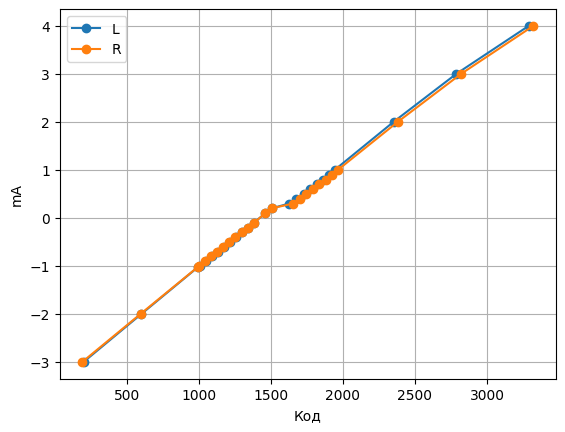

In [20]:
plt.plot(Lcodes, mA, 'o-', label='L')
plt.plot(Rcodes, mA, 'o-', label='R')
plt.legend()
plt.xlabel('Код')
plt.ylabel('mA')
plt.grid()
plt.show()

In [33]:
N_CODES = 4096
code_axis = np.arange(N_CODES, dtype=np.float64)


def cal_table_from_points(codes, ma, n=N_CODES):
    """mA = f(ADC code): линейная интерполяция + линейная экстраполяция за краями."""
    x = np.asarray(codes, dtype=np.float64)
    y = np.asarray(ma, dtype=np.float64)
    order = np.argsort(x)
    x, y = x[order], y[order]
    # дубликаты кодов (если вдруг) — усредняем mA
    xu, inv = np.unique(x, return_inverse=True)
    if len(xu) < len(x):
        yu = np.zeros_like(xu)
        cnt = np.zeros_like(xu)
        for i, j in enumerate(inv):
            yu[j] += y[i]
            cnt[j] += 1
        y = yu / cnt
        x = xu
    f = interp1d(x, y, kind="linear", fill_value="extrapolate", bounds_error=False)
    return f(code_axis)



mean_codes = (np.array(Lcodes)+np.array(Rcodes))/2
cal_l = cal_table_from_points(Lcodes, mA)
cal_r = cal_table_from_points(Rcodes, mA)
cal_mean = cal_table_from_points(mean_codes, mA)


In [47]:
err_l = (cal_l - cal_mean)
err_r = (cal_r - cal_mean)

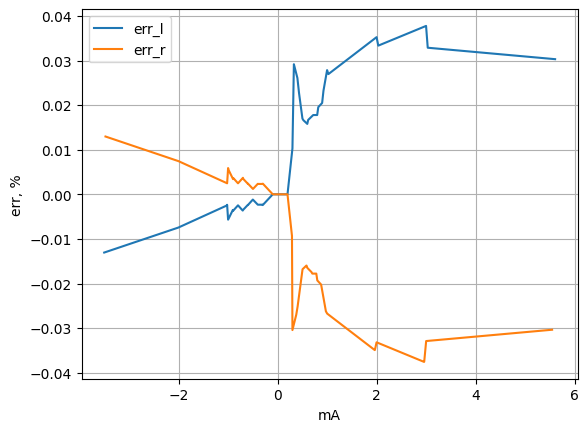

In [48]:
plt.plot(cal_l, err_l, label='err_l')
plt.plot(cal_r, err_r, label='err_r')
plt.legend()
plt.xlabel('mA')
plt.ylabel('err, %')
plt.grid()
plt.show()


In [53]:
print([round(float(v), 3) for v in cal_mean])

[-3.491, -3.488, -3.486, -3.483, -3.481, -3.478, -3.476, -3.473, -3.471, -3.468, -3.466, -3.463, -3.461, -3.458, -3.456, -3.453, -3.451, -3.448, -3.446, -3.443, -3.441, -3.439, -3.436, -3.434, -3.431, -3.429, -3.426, -3.424, -3.421, -3.419, -3.416, -3.414, -3.411, -3.409, -3.406, -3.404, -3.401, -3.399, -3.396, -3.394, -3.391, -3.389, -3.386, -3.384, -3.381, -3.379, -3.376, -3.374, -3.371, -3.369, -3.366, -3.364, -3.361, -3.359, -3.357, -3.354, -3.352, -3.349, -3.347, -3.344, -3.342, -3.339, -3.337, -3.334, -3.332, -3.329, -3.327, -3.324, -3.322, -3.319, -3.317, -3.314, -3.312, -3.309, -3.307, -3.304, -3.302, -3.299, -3.297, -3.294, -3.292, -3.289, -3.287, -3.284, -3.282, -3.28, -3.277, -3.275, -3.272, -3.27, -3.267, -3.265, -3.262, -3.26, -3.257, -3.255, -3.252, -3.25, -3.247, -3.245, -3.242, -3.24, -3.237, -3.235, -3.232, -3.23, -3.227, -3.225, -3.222, -3.22, -3.217, -3.215, -3.212, -3.21, -3.207, -3.205, -3.202, -3.2, -3.198, -3.195, -3.193, -3.19, -3.188, -3.185, -3.183, -3.18, -3.